In [1]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [2]:
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams["figure.dpi"] = 150

## Labeled adata
From: Finalize annotations
https://github.com/aifimmunology/spatial_mouse_drg/blob/main/yano/notebooks/04_neurons/02_finalize-annotations.ipynb

In [3]:
# from projects/drg
adata_path = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/drg/data/h5ad/export_04/04c_gamma_subtypes/-draft.h5ad"
adata_ref_path = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/drg/data/h5ad/export_01/01b_filter/adata-480.h5ad" # try this instead

output_dir = "/home/workspace/DRG/spatial_mouse_drg_outputs/Artis"

plot_out_dir = os.path.join(output_dir, "plots")
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

In [5]:
# adata = sc.read_h5ad(adata_path)

In [6]:
adata_ref = sc.read_h5ad(adata_ref_path)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/drg/data/h5ad/export_01/01b_filter/adata-480.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
print(adata.shape)
print(adata_ref.shape)

In [251]:
# subset adata_ref to only include the cells in adata (only neurons?)
# adata_ref = adata_ref[adata_ref.obs.index.isin(adata.obs.index), :]

In [252]:
adata_ref

AnnData object with n_obs × n_vars = 72778 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch'
    obsm: 'spatial'
    layers: 'counts'

In [253]:
print(min(adata.obs['total_counts']))
print(min(adata_ref.obs['total_counts']))

51.0
51.0


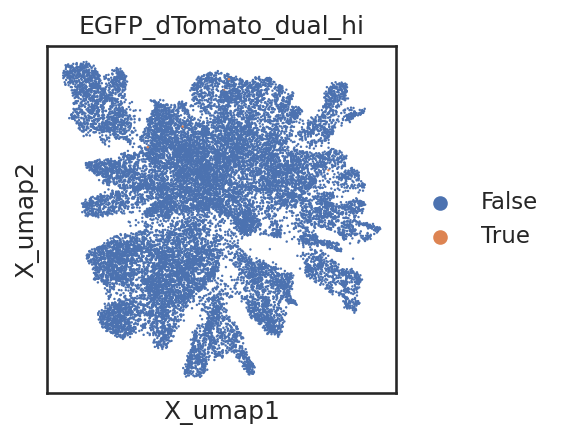

In [254]:
sc.pl.embedding(adata, basis = 'X_umap', color = 'EGFP_dTomato_dual_hi')

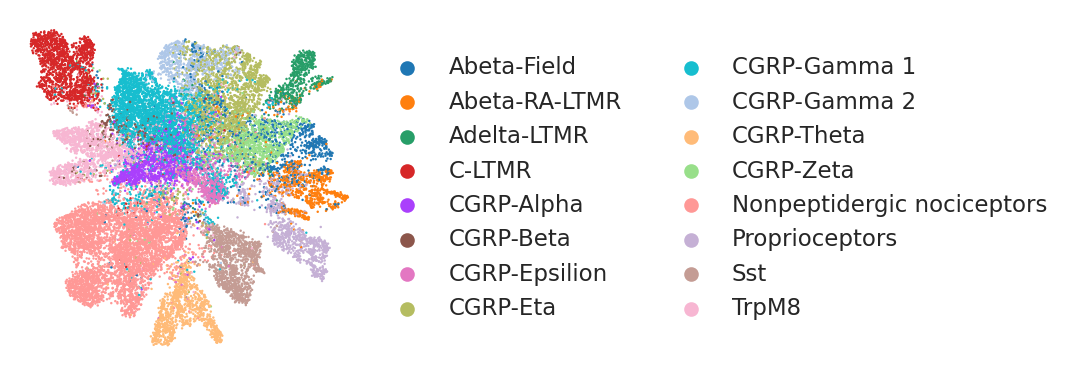

In [257]:
sc.pl.embedding(adata, basis = 'X_umap', color = 'neuron_label', frameon= False, title = '', show=False)
plt.savefig(os.path.join(plot_out_dir, 'umap_neuron_label.png'), format='png', bbox_inches='tight')


In [258]:
# neurons where thresholded at 1000 transcripts/cell
min(adata.obs['total_counts'])

51.0

## Plot reporter group

In [259]:
import matplotlib.pyplot as plt


def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
    save_path  = None
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")  # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(os.path.join(save_path, f"umap_{col}.png"), format='png', bbox_inches='tight')

        plt.show()

In [260]:
def barplot_dual_distribution(
    adata,
    population_name,
    group_col="neuron_label",
    dual_col="EGFP_dTomato_dual_hi",
    bar_color="black",
    figsize=(4, 4),
    fontsize=11,
    plot_counts = True,
    return_group_order=False,
    group_order=None,
):
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()

    total_dual = dual_counts.sum()
    print('number +: ', total_dual)

    # percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

    if group_order is not None:
        # Use the provided order. .reindex ensures we handle missing/extra groups safely.
        # Fill missing groups with 0 so the bars show up as empty instead of crashing.
        stats = stats.reindex(group_order).fillna(0)
    else:
        # Default: Sort by percentage descending
        stats = stats.sort_values(ascending=False)
    
    # Final order of categories
    final_order = stats.index.tolist()
    sorted_counts = dual_counts.reindex(final_order).fillna(0)

    # # ordered counts
    # sorted_counts = dual_counts.loc[stats.index]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(stats))
    if plot_counts:
        ax.bar(x, sorted_counts.values, color=bar_color, alpha=0.9)
    else:
        ax.bar(x, stats.values, color=bar_color, alpha=0.9)

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=45, ha="right", fontsize=fontsize)

    # y-axis
    if plot_counts:
        ax.set_ylabel("Count", fontsize=fontsize)
    else:     
        ax.set_ylim(0, 100)  # <-- force axis to show full 0–100%
        ax.set_ylabel(f"% of {population_name} \nneurons", fontsize=fontsize)
    ax.set_xlabel("")

    # minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    plt.subplots_adjust(bottom=0.28)
    if return_group_order:
        return fig, final_order
    return fig

In [261]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

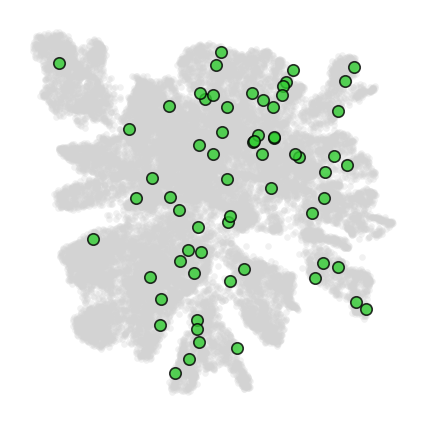

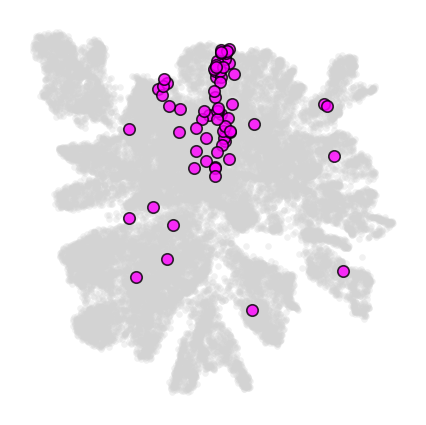

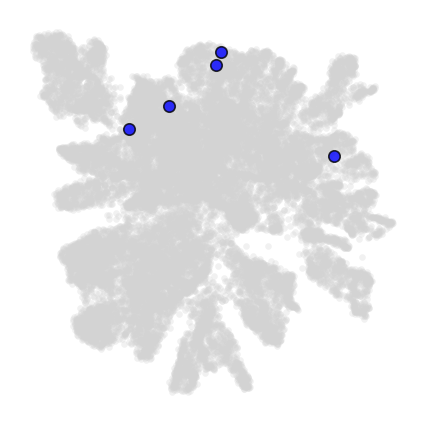

In [262]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = None
)

In [263]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    21774
True         5
Name: count, dtype: int64

## Export Neuron annotations for Xenium Explorer 
- To get the barcodes to match in xenium explorer, we need to separate into individual Xenium outputs and remove the trailing -0, -1, -2, or -3

In [264]:
adata.obs['sample_id'].unique()

['TMA00317', 'TMA00315', 'TMA00318', 'TMA00316']
Categories (4, object): ['TMA00315', 'TMA00316', 'TMA00317', 'TMA00318']

### Make label annotations df

In [265]:
label_cols = ["sample_id","neuron_label","EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]
label_df = adata.obs[label_cols]

index_clipped = ["-".join(barcode.split('-')[0:2]) for barcode in label_df.index]
label_df.index = index_clipped
label_df = label_df.reset_index(names='cell_id')

In [266]:
label_df.head()

,cell_id,sample_id,neuron_label,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi
0,aaahbdia-1,TMA00317,Nonpeptidergic nociceptors,False,False,False
1,aaakgcko-1,TMA00317,Abeta-RA-LTMR,False,False,False
2,aaanbmpi-1,TMA00317,Nonpeptidergic nociceptors,False,False,False
3,aaangnjd-1,TMA00317,Adelta-LTMR,False,False,False
4,aabakkkd-1,TMA00317,CGRP-Eta,False,False,False


### Output csvs with neuron label

In [267]:
output_dir

'/home/workspace/DRG/spatial_mouse_drg_outputs/Artis'

In [268]:
# for Xenium explorer, can only have one group
label_df_neuron_label = label_df.copy()
label_df_neuron_label['group'] = label_df_neuron_label['neuron_label']

# split to individual samples
for sample in adata.obs['sample_id'].unique().tolist():
    label_df_sample = label_df_neuron_label[label_df_neuron_label['sample_id']==sample]
    # save to csv 
    label_df_sample.to_csv(os.path.join(output_dir, f"label_df_{sample}_neuron_label.csv"),index=False)

### Output csvs with reporter status

In [269]:
# for Xenium explorer, can only have one group
label_df_reporter = label_df.copy()

# add reporter status, either single positive or double postivie
label_df_reporter['reporter_status'] = 'none'
label_df_reporter.loc[label_df_reporter['EGFP_Seq1_hi']==True, 'reporter_status'] = 'EGFP_Seq1_hi'
label_df_reporter.loc[label_df_reporter['dTomato_Seq2_hi']==True, 'reporter_status'] = 'dTomato_Seq2_hi'
label_df_reporter.loc[label_df_reporter['EGFP_dTomato_dual_hi']==True, 'reporter_status'] = 'EGFP_dTomato_dual_hi'

label_df_reporter['group'] = label_df_reporter['reporter_status']

# split to individual samples
for sample in adata.obs['sample_id'].unique().tolist():
    label_df_sample = label_df_reporter[label_df_reporter['sample_id']==sample]
    # save to csv 
    label_df_sample.to_csv(os.path.join(output_dir, f"label_df_{sample}_reporter.csv"),index=False)

In [270]:
# check with sample the double positive cells are in
counts = label_df.value_counts(['sample_id', 'EGFP_dTomato_dual_hi'])
counts

sample_id  EGFP_dTomato_dual_hi
TMA00316   False                   6076
TMA00315   False                   5954
TMA00318   False                   5046
TMA00317   False                   4698
TMA00316   True                       3
TMA00315   True                       1
TMA00318   True                       1
Name: count, dtype: int64

## Reclassify double positive cells after manual inspection

In [272]:
# load csv with manual reclassification
reclassify_df = pd.read_csv("reporter_label_reclassify.csv")
reclassify_df

# update index to include the sample-specific suffic
barcode_matching = adata.obs[['sample_id']].copy()
barcode_matching['suffix'] = [barcode.split('-')[2] for barcode in barcode_matching.index]
barcode_matching = barcode_matching.drop_duplicates().reset_index(drop=True)
suffix_dict = dict(zip(barcode_matching['sample_id'], barcode_matching['suffix']))
reclassify_df.index = reclassify_df['barcode'].astype(str) + "-" + reclassify_df['sample_id'].map(suffix_dict).astype(str)

# reclassify in adata object, first saving original
adata_original = adata.copy()
# will be NaN if no update
adata.obs = adata.obs.join(reclassify_df[['updated_label']])

adata.obs.loc[~adata.obs['updated_label'].isna(), 'EGFP_Seq1_hi']= False
adata.obs.loc[~adata.obs['updated_label'].isna(), 'dTomato_Seq2_hi']= False
adata.obs.loc[~adata.obs['updated_label'].isna(), 'EGFP_dTomato_dual_hi']= False

In [273]:
reclassify_df

,sample_id,barcode,original_label,updated_label
ilmfndhn-1-1,TMA00315,ilmfndhn-1,EGFP_dTomato_dual_hi,none
jalppfof-1-3,TMA00316,jalppfof-1,EGFP_dTomato_dual_hi,none


## Visualize after reclassification

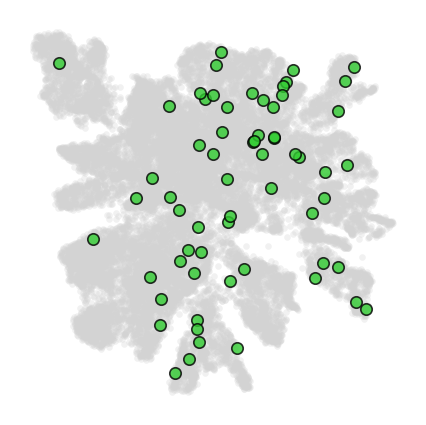

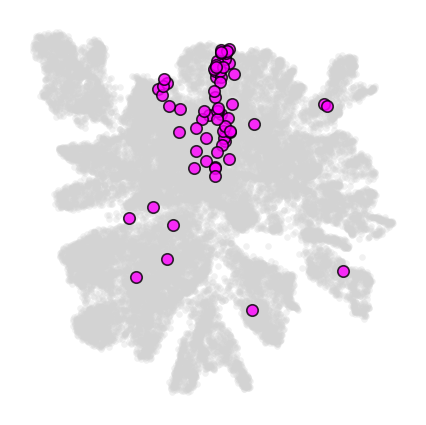

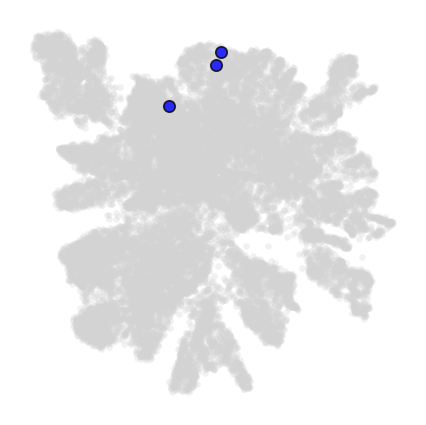

In [274]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = plot_out_dir
)

In [275]:
### Previous version which exluces cells that are expressing <2 transcripts of either reporter

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

from scipy.stats import norm

def plot_gaussian_previous(adata, adata_ref, 
                  highlight_barcodes=None, 
                  highlight_color = 'orange',
                  save_path = None, return_reporter_classes = False,
                 threshold_percentile = 0.99):
    adata = adata.copy()
    adata_ref = adata_ref.copy()

    adata_list = [adata, adata_ref]
    for ad in adata_list:
        ad.var_names = ad.var_names.where(ad.var_names != "tdTomato_Seq2", "dTomato_Seq2")

    adata.X = adata.layers["counts"].copy()
    adata_ref.X = adata_ref.layers["counts"].copy()
    
    genes = ["EGFP_Seq1", "dTomato_Seq2"]
    
    # Raw counts for filtering
    egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
    td_raw_all = to_dense(adata_ref[:, "dTomato_Seq2"].X)
    
    # Filter to include only cells with >1 raw count in both genes
    bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)
    
    gauss_results = {}
    for g in genes:
        x_raw_full = to_dense(adata_ref[:, g].X)
        x_raw = x_raw_full[bg_filter]
        x_log = np.log1p(x_raw)

        mu, sigma = np.mean(x_log), np.std(x_log)
        # calculate multplier for xth percentile of log gaussian distribution
        multiplier = norm.ppf(threshold_percentile)
        print(f"{threshold_percentile} percentile multiplier for {g}: {multiplier:.3f}")
        # thr_log = mu + 2.326 * sigma
        thr_log = mu + multiplier * sigma
        
        hi_mask = np.zeros(adata_ref.n_obs, dtype=bool)
        hi_mask[bg_filter] = x_log > thr_log
        adata_ref.obs[f"{g}_hi"] = hi_mask
        gauss_results[g] = {"x_log": x_log, "thr_log": thr_log}
    
    # Identify Dual-high
    adata_ref.obs["EGFP_dTomato_dual_hi"] = (
        adata_ref.obs["EGFP_Seq1_hi"] & adata_ref.obs["dTomato_Seq2_hi"]
    )
    
    # --- New Logic for Manual highlight ---
    # Create a mask for highlight cells within the filtered background
    is_highlight = np.zeros(adata_ref.n_obs, dtype=bool)
    if highlight_barcodes is not None:
        is_highlight = adata_ref.obs_names.isin(highlight_barcodes)
    
    # Subsets for plotting (only for cells that passed bg_filter)
    dual_mask = adata_ref.obs["EGFP_dTomato_dual_hi"][bg_filter].values
    highlight_mask = is_highlight[bg_filter]
    
    # Only color as "Dual" if it is dual-high AND NOT excluded
    final_dual = dual_mask & ~highlight_mask
    # Only color as "Excluded" if it was dual-high but is in our list
    # final_excluded = dual_mask & excluded_mask
    final_highlight = highlight_mask
    # --------------------------------------

    x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
    x_td_log = gauss_results["dTomato_Seq2"]["x_log"]
    thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
    thr_td_log = gauss_results["dTomato_Seq2"]["thr_log"]

    # Plot
    sns.set_theme(style="ticks")
    plt.figure(figsize=(3,3), dpi=300)
    ax = plt.gca()
    
    # 1. Background (Gray)
    ax.scatter(x_egfp_log, x_td_log, s=3, color="gray", alpha=0.15, label="Background")
    
    # 2. Confirmed Dual High (Blue)
    ax.scatter(
        x_egfp_log[final_dual],
        x_td_log[final_dual],
        s=40, facecolors=(0.0, 0.47, 1.0, 0.45), edgecolors="blue", linewidths=1, label="Dual Positive"
    )
    
    # 3. Manual highlight
    if final_highlight.any():
        ax.scatter(
            x_egfp_log[final_highlight],
            x_td_log[final_highlight],
            s=40, facecolors=(0.3, 0.3, 0.3, 0.6), edgecolors=highlight_color, linewidths=1, label="Highlight"
        )
    
    ax.axvline(thr_egfp_log, color="red", ls="--", lw=1.5)
    ax.axhline(thr_td_log, color="red", ls="--", lw=1.5)
    
    ax.set_xlabel("log1p EGFP")
    ax.set_ylabel("log1p dTomato")
    # ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    
    sns.despine()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(os.path.join(save_path, "gaussian_reclassified.png"), format='png', bbox_inches='tight')
    plt.show()

    if return_reporter_classes:
        reporter_classes_df = adata_ref.obs[['sample_id', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi','EGFP_dTomato_dual_hi']]
        return reporter_classes_df
        

In [290]:
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

from scipy.stats import norm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

def plot_gaussian(adata_ref, 
                  highlight_barcodes=None, 
                  highlight_color='orange',
                  highlight_size = 30,
                  save_path=None, 
                  return_reporter_classes=False,
                  threshold_percentile=0.99,
                 show_histograms=False):
    
    # Work on copies to avoid unintended side effects
    adata_ref = adata_ref.copy()

    # Standardize gene names
    adata_ref.var_names = adata_ref.var_names.where(adata_ref.var_names != "tdTomato_Seq2", "dTomato_Seq2")
    
    # Ensure we are using raw counts for the math
    adata_ref.X = adata_ref.layers["counts"].copy()
    
    genes = ["EGFP_Seq1", "dTomato_Seq2"]
    gauss_results = {}

    for g in genes:
        # 1. Get full expression vector for this gene
        x_raw_full = to_dense(adata_ref[:, g].X)
        x_log_full = np.log1p(x_raw_full)
        
        # 2. INDEPENDENT Background Filter
        # We only use cells with >1 count in THIS gene to model the noise
        specific_bg = x_raw_full > 1 
        
        x_log_bg = x_log_full[specific_bg]
        
        # 3. Calculate Gaussian parameters from this gene's noise
        mu, sigma = np.mean(x_log_bg), np.std(x_log_bg)
        multiplier = norm.ppf(threshold_percentile)
        thr_log = mu + multiplier * sigma
        
        # 4. Apply threshold to ALL cells
        # Now a cell with 0 dTomato can still be EGFP_hi
        adata_ref.obs[f"{g}_hi"] = x_log_full > thr_log
        
        gauss_results[g] = {
            "full_log": x_log_full, 
            "thr_log": thr_log
        }
        print(f"{g}: {threshold_percentile} percentile threshold set at {thr_log:.3f} (Z={multiplier:.3f})")

        if show_histograms:
                    plt.figure(figsize=(4, 3))
                    # Plot the background distribution used for the model
                    plt.hist(x_log_bg, bins=100, color='gray', alpha=0.7)
                    # Add the threshold line
                    plt.axvline(thr_log, color='red', linestyle='--', label=f'Threshold: {thr_log:.2f}')
                    plt.title(f"Background Distribution: {g}")
                    plt.xlabel("log1p Expression")
                    plt.ylabel("Frequency")
                    plt.ylim(0,100)
                    plt.legend()
                    sns.despine()
                    plt.show() # This ensures the plot renders before the next loop iteration


    # Identify Dual-high (Logical AND of independent results)
    adata_ref.obs["EGFP_dTomato_dual_hi"] = (
        adata_ref.obs["EGFP_Seq1_hi"] & adata_ref.obs["dTomato_Seq2_hi"]
    )

    # --- Highlight Logic ---
    is_highlight = adata_ref.obs_names.isin(highlight_barcodes) if highlight_barcodes is not None else np.zeros(adata_ref.n_obs, dtype=bool)
    
    # Define plotting groups
    dual_mask = adata_ref.obs["EGFP_dTomato_dual_hi"].values
    final_dual = dual_mask & ~is_highlight
    final_highlight = is_highlight
    
    # --- Plotting ---
    x_egfp = gauss_results["EGFP_Seq1"]["full_log"]
    x_td = gauss_results["dTomato_Seq2"]["full_log"]
    
    sns.set_theme(style="ticks")
    plt.figure(figsize=(3, 3), dpi=300)
    ax = plt.gca()

    # 1. All cells (Background)
    ax.scatter(x_egfp, x_td, s=2, color="lightgray", alpha=0.2, label="Background", rasterized=True)

    # 2. Dual Positive cells (Blue)
    if final_dual.any():
        ax.scatter(x_egfp[final_dual], x_td[final_dual], 
                   s=30, facecolors=(0.0, 0.47, 1.0, 0.4), edgecolors="blue", 
                   linewidths=0.8, label="Dual Positive")

    # 3. Highlighted cells (Orange/Custom) - Drawn last with high zorder
    if final_highlight.any():
        ax.scatter(x_egfp[final_highlight], x_td[final_highlight], 
                   s=highlight_size, facecolors=highlight_color, 
                   alpha=1.0, label="Highlighted", zorder=10)

    # Threshold lines
    ax.axvline(gauss_results["EGFP_Seq1"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)
    ax.axhline(gauss_results["dTomato_Seq2"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)

    ax.set_xlabel("log1p EGFP_Seq1")
    ax.set_ylabel("log1p dTomato_Seq2")
    sns.despine()
    
    if save_path:
        plt.savefig(os.path.join(save_path, "independent_gaussian_thresholds.pdf"), bbox_inches='tight')
    plt.show()

    if return_reporter_classes:
        return adata_ref.obs[['sample_id', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']]

In [277]:
# previous
# plot_gaussian(adata, adata_ref, highlight_barcodes=reclassify_df.index.tolist())

In [278]:
counts = adata.obs.value_counts(['sample_id', 'EGFP_dTomato_dual_hi'])
counts

sample_id  EGFP_dTomato_dual_hi
TMA00316   False                   6077
TMA00315   False                   5955
TMA00318   False                   5046
TMA00317   False                   4698
TMA00316   True                       2
TMA00318   True                       1
Name: count, dtype: int64

### Barplot - counts of each reporter 

In [279]:
plot_out_dir

'/home/workspace/DRG/spatial_mouse_drg_outputs/Artis/plots'

number +:  3
number +:  63
number +:  67


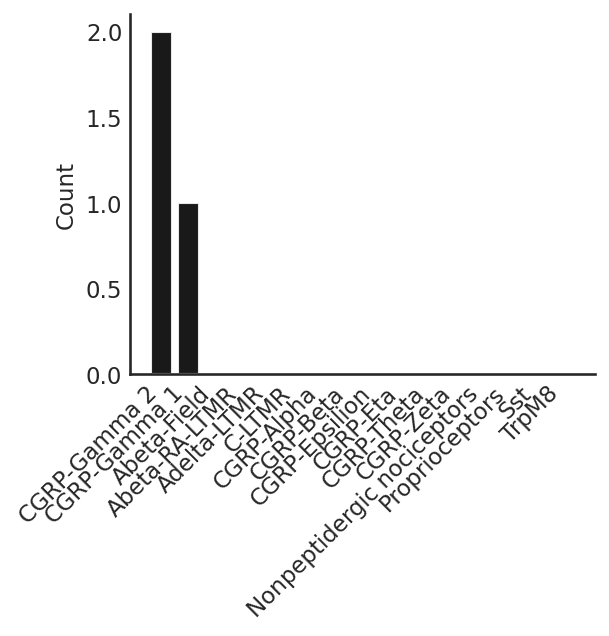

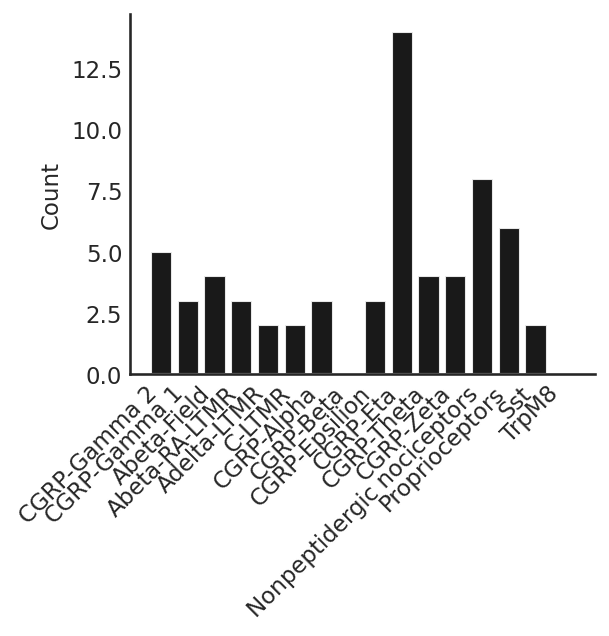

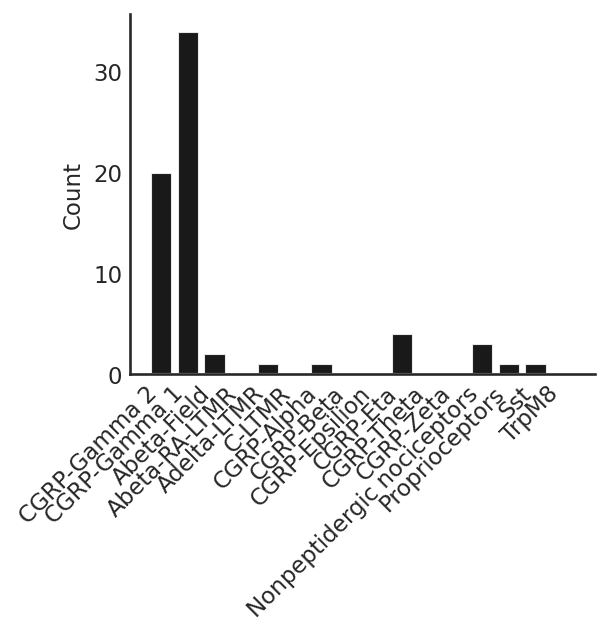

In [280]:
# set cell type order based on dual positive order
_, dual_order = barplot_dual_distribution(adata, population_name = 'Double+',
                                          dual_col="EGFP_dTomato_dual_hi",
                          return_group_order=True,
                            group_order=None)   
plt.savefig(os.path.join(plot_out_dir, "dual_distribution_count.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata,population_name = 'EGFP+',
                          dual_col="EGFP_Seq1_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_count.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata,population_name = 'dTomato+',
                          dual_col="dTomato_Seq2_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_count.pdf"), format='pdf', bbox_inches='tight')



## Testing updates to reporter thresholding code

EGFP_Seq1: 0.99 percentile threshold set at 2.901 (Z=2.326)
dTomato_Seq2: 0.99 percentile threshold set at 2.046 (Z=2.326)


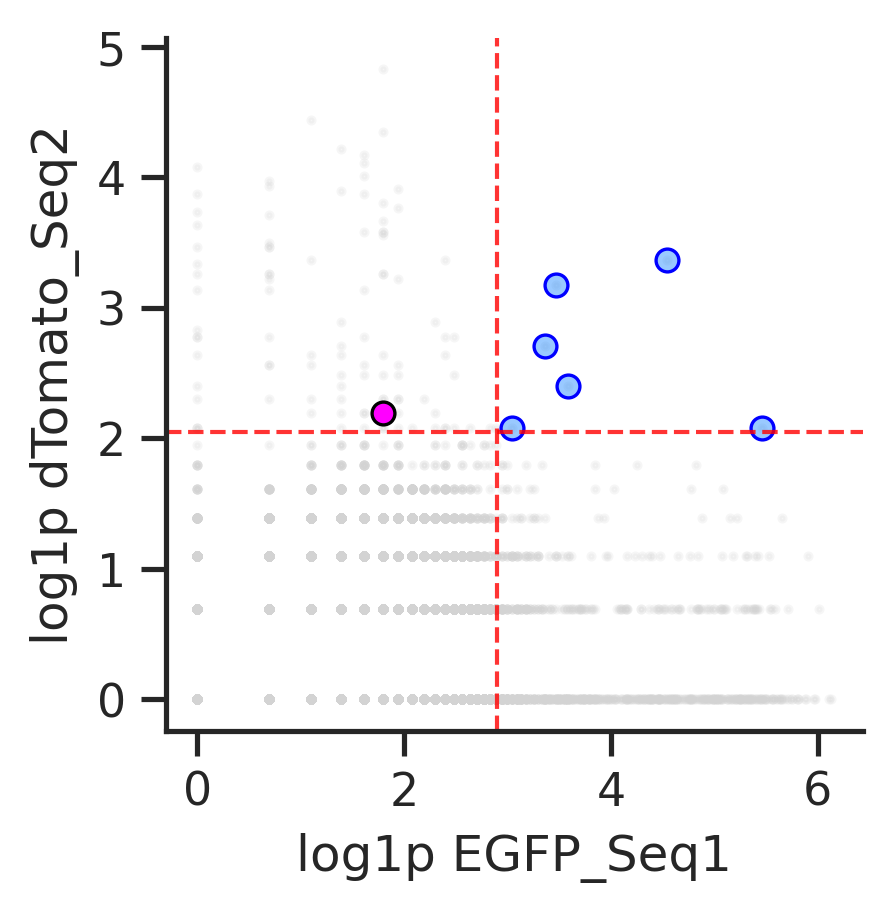

788
107
6


In [282]:
reporter_classes_99_updated = plot_gaussian(adata_ref, return_reporter_classes = True, threshold_percentile = 0.99,
                                 # highlight_barcodes=['acnndfag-1-3','bdfecjda-1-3','aceaecde-1-3'], # previously not identified
                                   highlight_barcodes=['nefgajla-1-3'], # false positive?
                                   highlight_color = 'magenta', show_histograms=False)

print(sum(reporter_classes_99_updated['EGFP_Seq1_hi']))
print(sum(reporter_classes_99_updated['dTomato_Seq2_hi']))
print(sum(reporter_classes_99_updated['EGFP_dTomato_dual_hi']))


EGFP_Seq1: 0.99 percentile threshold set at 2.901 (Z=2.326)
dTomato_Seq2: 0.99 percentile threshold set at 2.046 (Z=2.326)


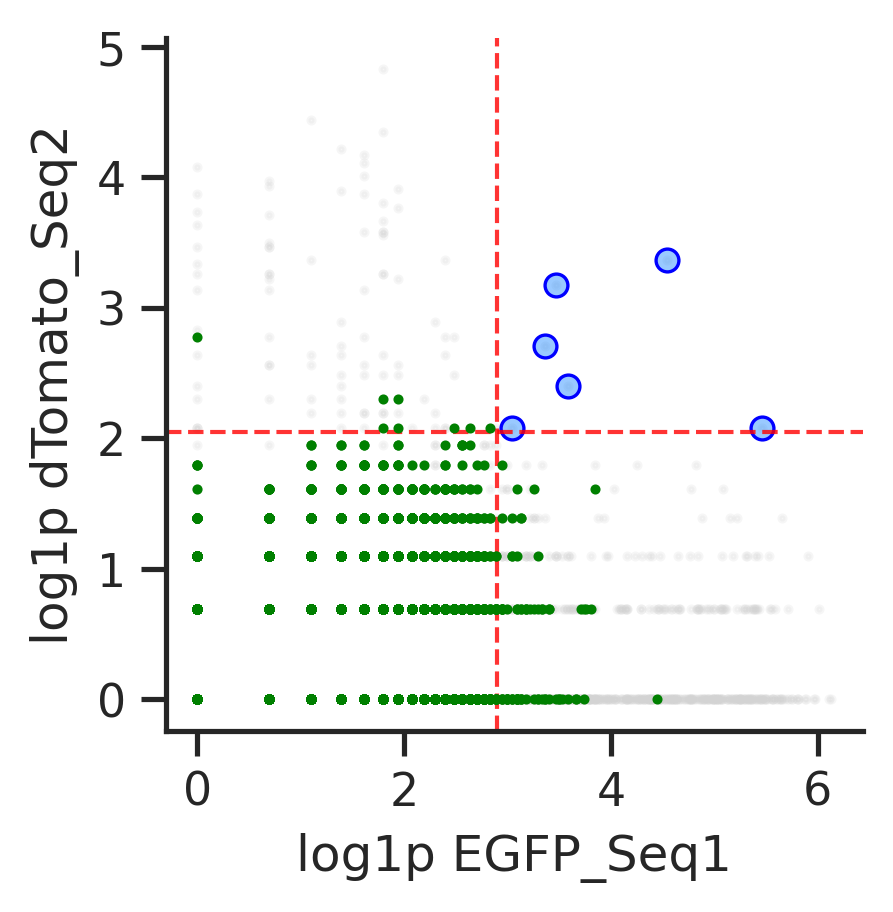

In [293]:
# highlight non neuronal
not_in_adata = adata_ref[~adata_ref.obs.index.isin(adata.obs.index), :].obs.index.tolist()

plot_gaussian(adata_ref, return_reporter_classes = False, threshold_percentile = 0.99,
                                   highlight_barcodes=not_in_adata,
                                   highlight_color = 'green', 
                                      highlight_size = 2,                       
              show_histograms=False)


In [294]:
# what if we exclude non neuronal before doing the thresholding?

EGFP_Seq1: 0.99 percentile threshold set at 3.407 (Z=2.326)
dTomato_Seq2: 0.99 percentile threshold set at 2.448 (Z=2.326)


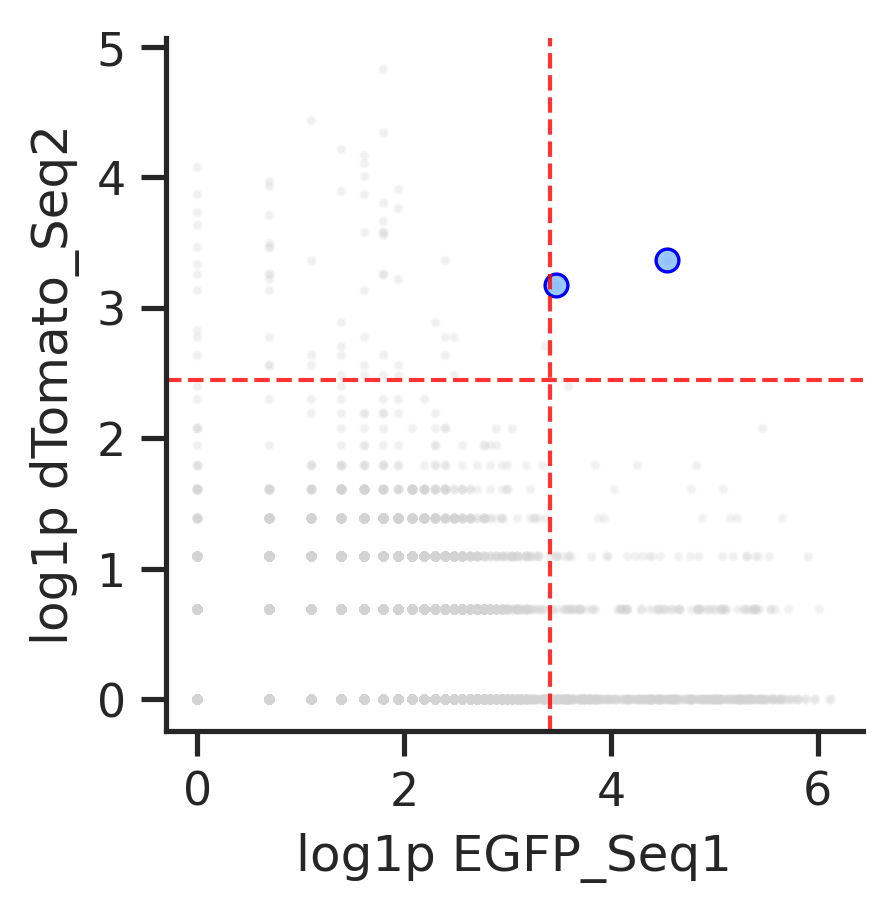

In [295]:
# highlight non neuronal
not_in_adata = adata_ref[~adata_ref.obs.index.isin(adata.obs.index), :].obs.index.tolist()
adata_ref_subset = adata_ref[adata_ref.obs.index.isin(adata.obs.index), :].copy()

plot_gaussian(adata_ref_subset, return_reporter_classes = False, threshold_percentile = 0.99,
                                   highlight_barcodes=not_in_adata,
                                   highlight_color = 'green', 
                                      highlight_size = 2,                       
              show_histograms=False)


EGFP_Seq1: 0.99 percentile threshold set at 2.901 (Z=2.326)
dTomato_Seq2: 0.99 percentile threshold set at 2.046 (Z=2.326)


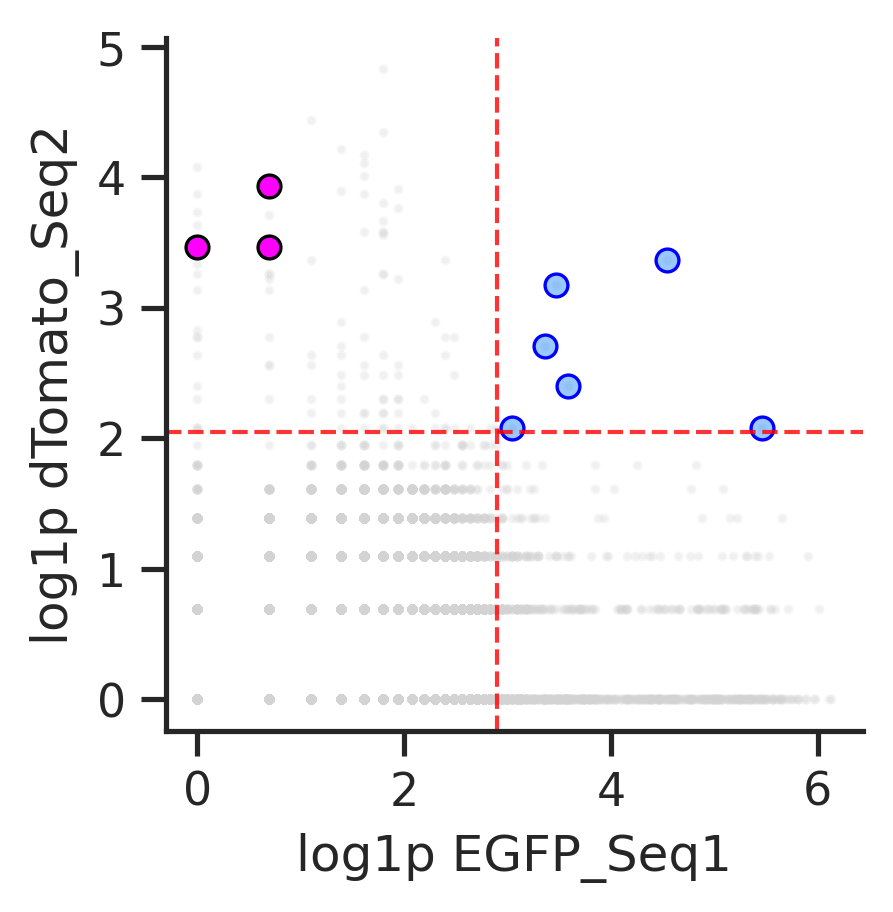

788
107
6


In [180]:
reporter_classes_99_updated = plot_gaussian(adata_ref, return_reporter_classes = True, threshold_percentile = 0.99,
                                 highlight_barcodes=['acnndfag-1-3','bdfecjda-1-3','aceaecde-1-3'], # previously not identified
                                   # highlight_barcodes=['nefgajla-1-3'], # false positive?
                                   highlight_color = 'magenta')

print(sum(reporter_classes_99_updated['EGFP_Seq1_hi']))
print(sum(reporter_classes_99_updated['dTomato_Seq2_hi']))
print(sum(reporter_classes_99_updated['EGFP_dTomato_dual_hi']))


In [181]:
reporter_classes_99_updated

,sample_id,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi
aaabecpg-1-0,TMA00317,False,False,False
aaahbdia-1-0,TMA00317,False,False,False
aaahhimm-1-0,TMA00317,False,False,False
aaakgcko-1-0,TMA00317,False,False,False
aaanbmpi-1-0,TMA00317,False,False,False
...,...,...,...,...
ojahnobe-1-3,TMA00316,False,False,False
ojalbcnk-1-3,TMA00316,False,False,False
ojbdlmnl-1-3,TMA00316,False,False,False
ojcccdhh-1-3,TMA00316,False,False,False


In [182]:
# for Xenium explorer, can only have one group
label_df = reporter_classes_99_updated.copy()

index_clipped = ["-".join(barcode.split('-')[0:2]) for barcode in label_df.index]
label_df.index = index_clipped
label_df = label_df.reset_index(names='cell_id')

label_df_reporter = label_df.copy()

# add reporter status, either single positive or double postivie
label_df_reporter['reporter_status'] = 'none'
label_df_reporter.loc[label_df_reporter['EGFP_Seq1_hi']==True, 'reporter_status'] = 'EGFP_Seq1_hi'
label_df_reporter.loc[label_df_reporter['dTomato_Seq2_hi']==True, 'reporter_status'] = 'dTomato_Seq2_hi'
label_df_reporter.loc[label_df_reporter['EGFP_dTomato_dual_hi']==True, 'reporter_status'] = 'EGFP_dTomato_dual_hi'

label_df_reporter['group'] = label_df_reporter['reporter_status']

# split to individual samples
for sample in adata.obs['sample_id'].unique().tolist():
    label_df_sample = label_df_reporter[label_df_reporter['sample_id']==sample]
    # save to csv 
    label_df_sample.to_csv(os.path.join(output_dir, f"label_df_{sample}_reporter_99percentile_updated.csv"),index=False)

In [187]:
# Check counts per sample
reporter_counts = label_df_reporter.value_counts(['sample_id', 'reporter_status']).reset_index(name='cell_count')
reporter_counts = reporter_counts.sort_values(['sample_id', 'cell_count'], ascending=[True, False])
reporter_counts


,sample_id,reporter_status,cell_count
1,TMA00315,none,19172
5,TMA00315,EGFP_Seq1_hi,224
9,TMA00315,dTomato_Seq2_hi,27
13,TMA00315,EGFP_dTomato_dual_hi,2
0,TMA00316,none,19676
4,TMA00316,EGFP_Seq1_hi,241
10,TMA00316,dTomato_Seq2_hi,24
12,TMA00316,EGFP_dTomato_dual_hi,3
3,TMA00317,none,16138
7,TMA00317,EGFP_Seq1_hi,158


## Re-outputting umaps and distribution plots with updated thresholding

EGFP_Seq1: 0.99 percentile threshold set at 2.901 (Z=2.326)
dTomato_Seq2: 0.99 percentile threshold set at 2.046 (Z=2.326)


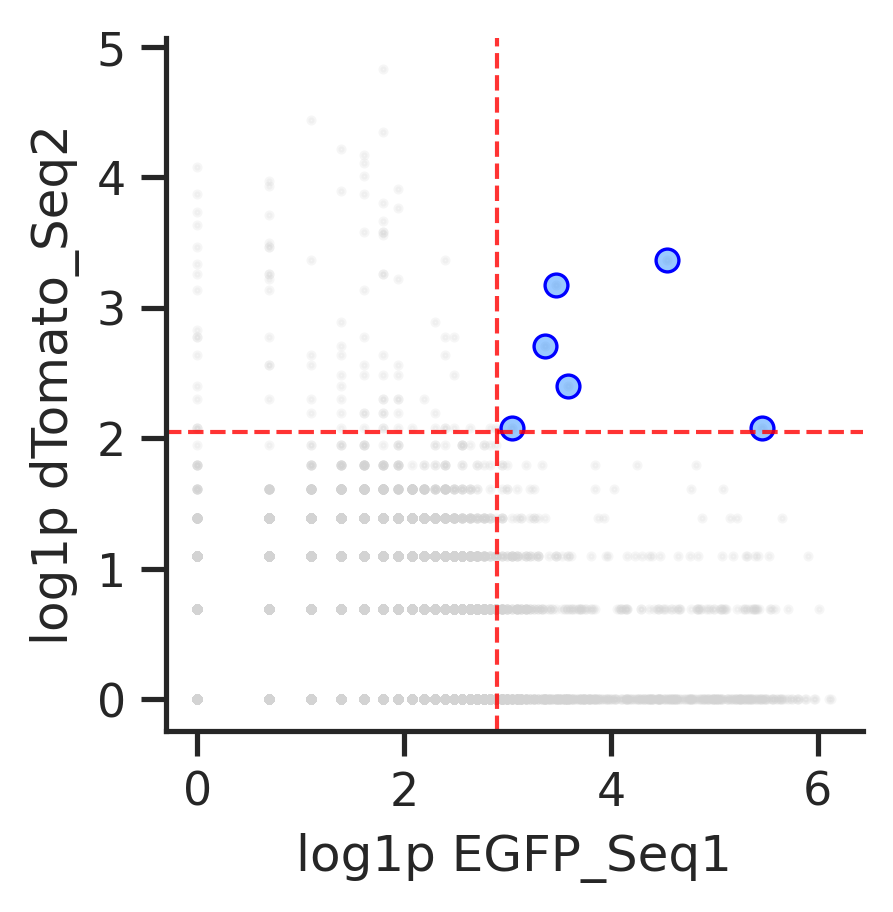

788
107
6


In [296]:
# first run filtering
reporter_classes_99_updated = plot_gaussian(adata_ref, return_reporter_classes = True, threshold_percentile = 0.99,
                                   highlight_color = 'magenta')

print(sum(reporter_classes_99_updated['EGFP_Seq1_hi']))
print(sum(reporter_classes_99_updated['dTomato_Seq2_hi']))
print(sum(reporter_classes_99_updated['EGFP_dTomato_dual_hi']))

### Make a new adata copy and apply these updated reporter labels

In [322]:
adata_updated = adata.copy()
del adata_updated.obs['EGFP_Seq1_hi']
del adata_updated.obs['dTomato_Seq2_hi']
del adata_updated.obs['EGFP_dTomato_dual_hi']
del adata_updated.obs['reporter_status']
del adata_updated.obs['updated_label']

In [323]:
adata_updated.obs = adata_updated.obs.join(reporter_classes_99_updated[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']])

### Now update with manual reclassifications

In [324]:
# # load csv with manual reclassification - updated to include the reclassification of the 6th computationally identified dual+ cell
# reclassify_df = pd.read_csv("reporter_label_reclassify.csv")
# reclassify_df

# # update index to include the sample-specific suffic
# barcode_matching = adata.obs[['sample_id']].copy()
# barcode_matching['suffix'] = [barcode.split('-')[2] for barcode in barcode_matching.index]
# barcode_matching = barcode_matching.drop_duplicates().reset_index(drop=True)
# suffix_dict = dict(zip(barcode_matching['sample_id'], barcode_matching['suffix']))
# reclassify_df.index = reclassify_df['barcode'].astype(str) + "-" + reclassify_df['sample_id'].map(suffix_dict).astype(str)

# # will be NaN if no update
# adata_updated.obs = adata_updated.obs.join(reclassify_df[['updated_label']])

# adata_updated.obs.loc[~adata_updated.obs['updated_label'].isna(), 'EGFP_Seq1_hi']= False
# adata_updated.obs.loc[~adata_updated.obs['updated_label'].isna(), 'dTomato_Seq2_hi']= False
# adata_updated.obs.loc[~adata_updated.obs['updated_label'].isna(), 'EGFP_dTomato_dual_hi']= False

### Now make updated plots

In [325]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

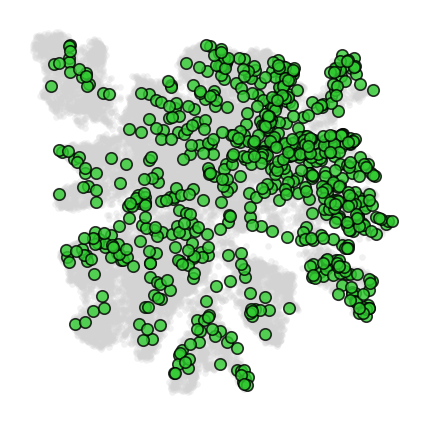

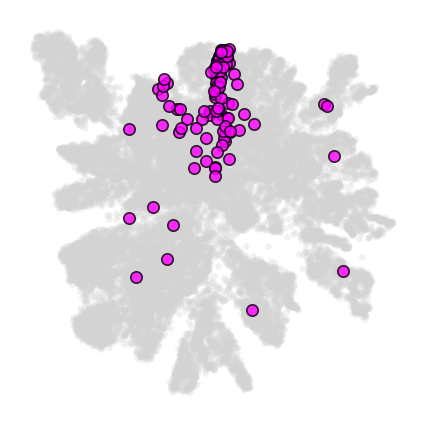

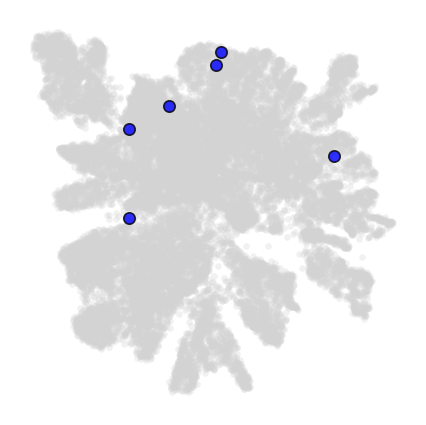

In [326]:
plot_umaps(
    adata_updated,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = plot_out_dir
)

number +:  6
number +:  715
number +:  99


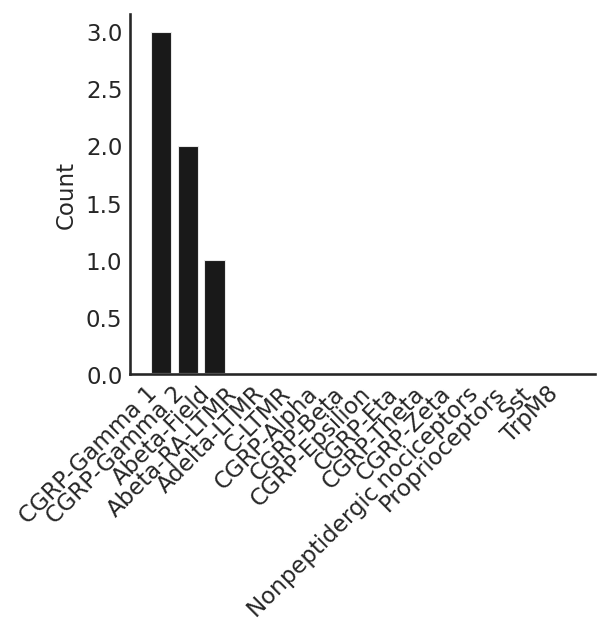

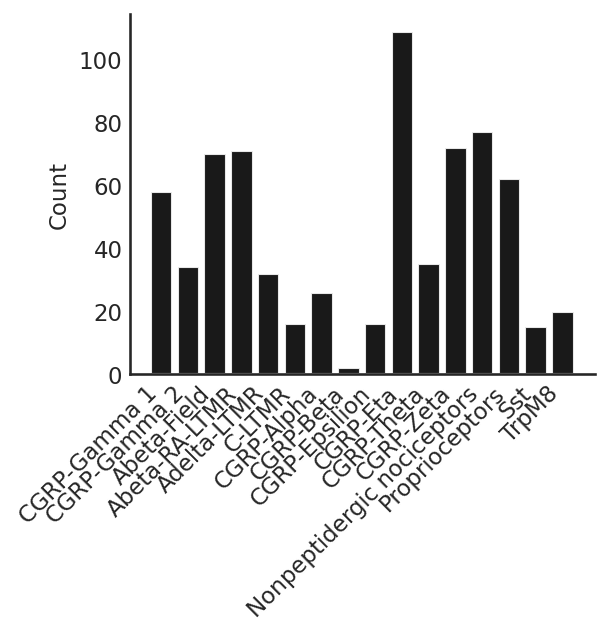

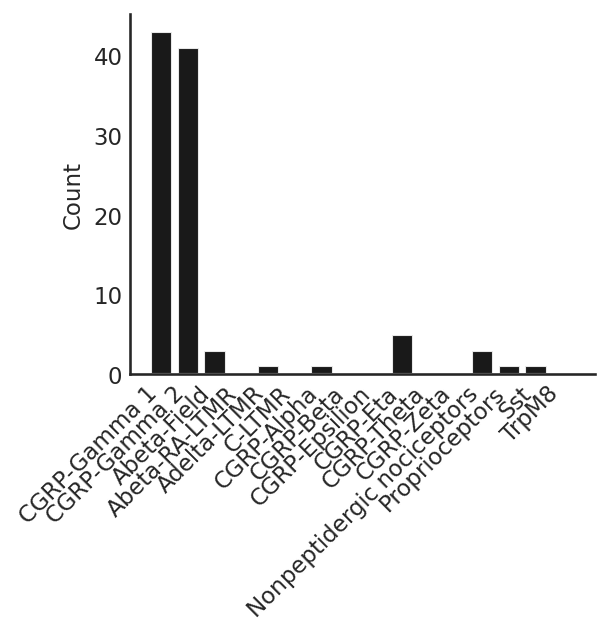

In [327]:
# set cell type order based on dual positive order
_, dual_order = barplot_dual_distribution(adata_updated, population_name = 'Double+',
                                          dual_col="EGFP_dTomato_dual_hi",
                          return_group_order=True,
                            group_order=None)   
plt.savefig(os.path.join(plot_out_dir, "dual_distribution_count_updated.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata_updated,population_name = 'EGFP+',
                          dual_col="EGFP_Seq1_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_count_updated.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata_updated,population_name = 'dTomato+',
                          dual_col="dTomato_Seq2_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_count_updated.pdf"), format='pdf', bbox_inches='tight')



In [328]:
print(adata.shape)
print(min(adata.obs['total_counts']))
print(sum(adata.obs['total_counts']<1000))

(21779, 475)
51.0
11503


In [329]:
adata_updated_1000 = adata_updated[adata_updated.obs['total_counts']>=1000 ,:].copy()

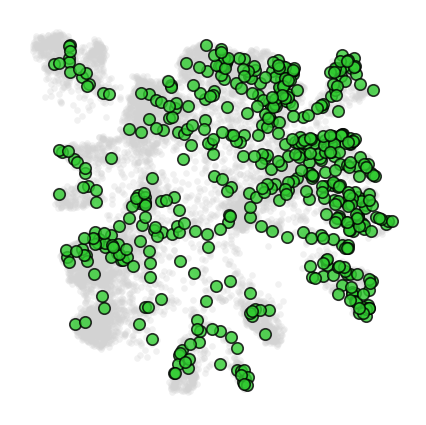

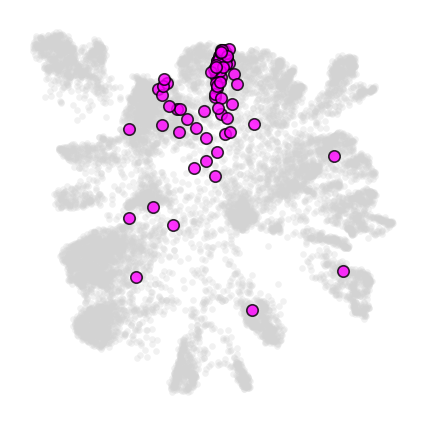

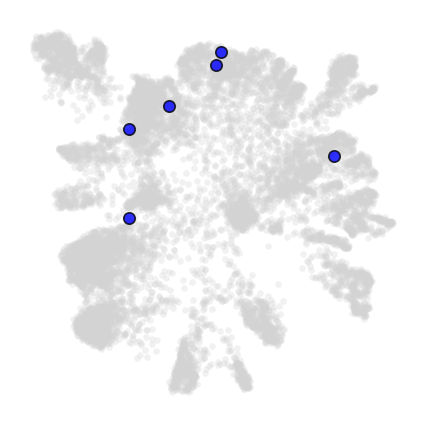

In [330]:
plot_umaps(
    adata_updated_1000,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = plot_out_dir
)

number +:  6
number +:  528
number +:  70


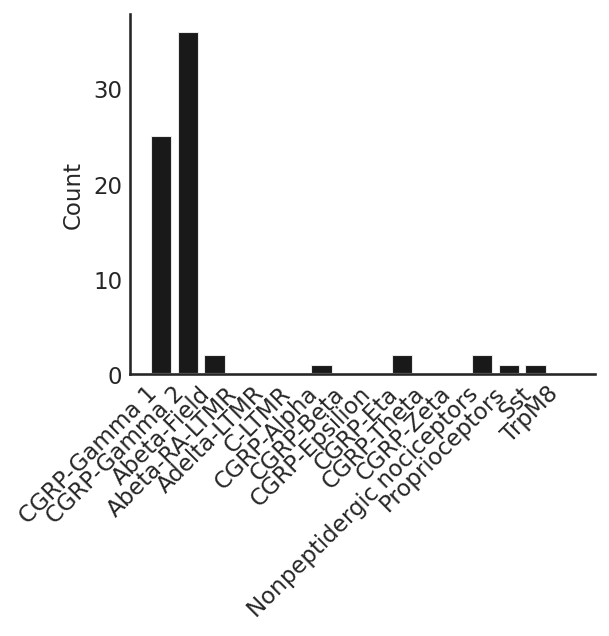

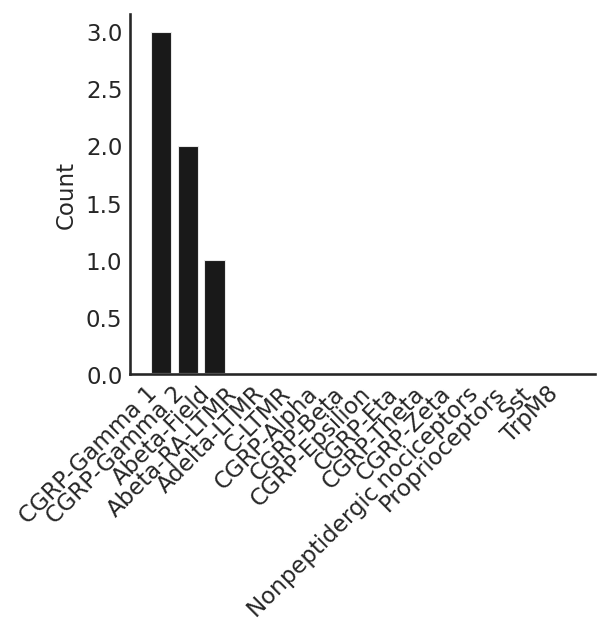

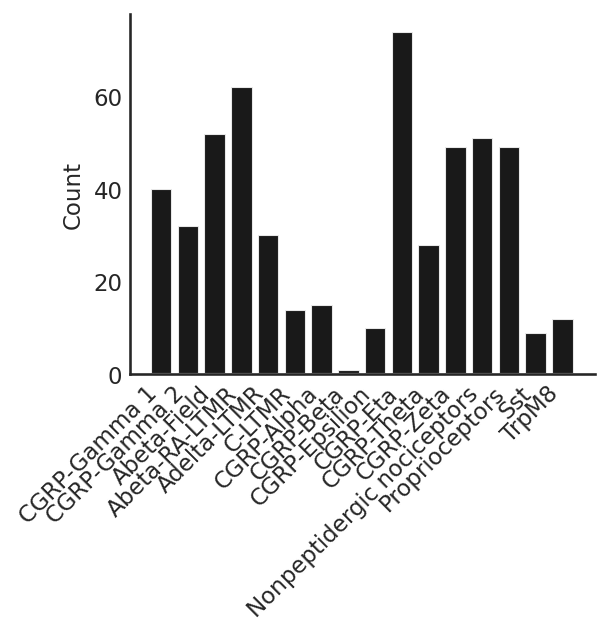

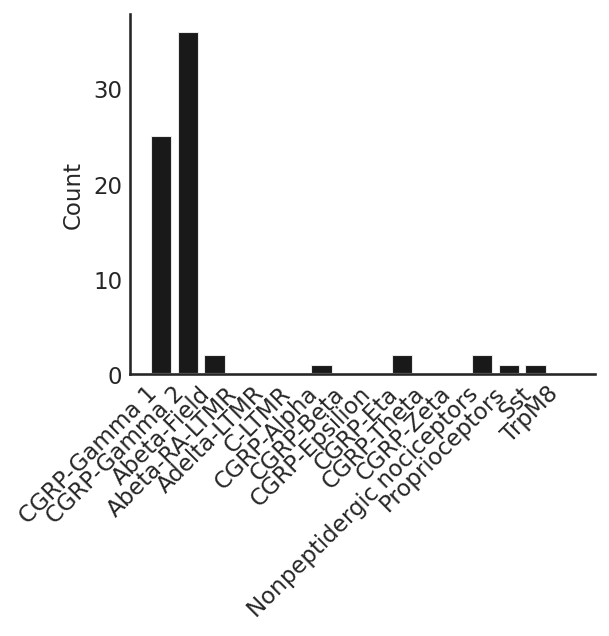

In [331]:
# set cell type order based on dual positive order
_, dual_order = barplot_dual_distribution(adata_updated_1000, population_name = 'Double+',
                                          dual_col="EGFP_dTomato_dual_hi",
                          return_group_order=True,
                            group_order=None)   

barplot_dual_distribution(adata_updated_1000,population_name = 'EGFP+',
                          dual_col="EGFP_Seq1_hi",
                         group_order = dual_order)

barplot_dual_distribution(adata_updated_1000,population_name = 'dTomato+',
                          dual_col="dTomato_Seq2_hi",
                         group_order = dual_order)

